# 2 — Convolutional Autoencoder Experiments

Progressive improvements to the baseline ConvAE, all trained on **P-only** (Pavement) patches.

| # | Variant | Key addition |
|---|---------|-------------|
| A | Baseline ConvAE | MSE loss, CosineAnnealingLR |
| B | ConvAE + SE | SE channel attention in encoder |
| C | ConvAE + CBAM | Spatial + channel attention in encoder |
| D | ConvAE + Perceptual | MSE + VGG-16 perceptual loss |

**Why AE and not SVDD for attention experiments?**  
Reconstruction loss prevents encoder collapse — SE/CBAM get proper gradient signal.  
In SVDD, the projection head collapses in 1–2 epochs, killing upstream attention gradients.

**Why perceptual loss?**  
Cracks are high-frequency texture patterns. VGG-16 mid-level features (relu2_2, relu3_3)  
capture texture structure — AE trained with perceptual loss finds crack texture harder to  
reconstruct, widening the anomaly score gap.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tvm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.dataset import build_image_index, CrackDataset, load_splits
from src.train_utils import eval_scores, calibrate_threshold, compute_metrics
from src.viz_utils import plot_roc_curve, plot_score_histogram, plot_confusion_matrix
from src.models import ConvAutoencoder


DATASET_DIR = 'SDNET2018'
SPLITS_DIR  = 'splits'
BATCH_SIZE  = 64
NUM_EPOCHS  = 30
PATIENCE    = 5
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
train_records, val_records, test_records = load_splits(SPLITS_DIR)

train_normal = [r for r in train_records if r['label'] == 0]
val_all      = val_records
test_all     = test_records

train_ds = CrackDataset(train_normal, preprocessing='none', augment=False)
val_ds   = CrackDataset(val_all,     preprocessing='none', augment=False)
test_ds  = CrackDataset(test_all,    preprocessing='none', augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

val_labels  = np.array([r['label'] for r in val_all])
test_labels = np.array([r['label'] for r in test_all])

print(f'Train normal: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')

Train normal: 15,207  |  Val: 3,650  |  Test: 3,651


## Shared Training Loop

In [5]:
def train_ae(
    model,
    train_loader,
    val_loader,
    val_labels,
    device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    lr=1e-3,
    weight_decay=1e-4,
    loss_fn=None,
    label=None,
):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    mse_crit  = nn.MSELoss()

    if loss_fn is None:
        loss_fn = lambda recon, x, m: mse_crit(recon, x)

    best_auroc  = 0.0
    best_state  = None
    no_improve  = 0
    train_losses, val_aurocs = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = loss_fn(recon, x, model)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        scores = []
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                s = model.anomaly_score(x)
                scores.append(s.cpu())
        scores = torch.cat(scores).numpy()
        auroc  = roc_auc_score(val_labels, scores)
        val_aurocs.append(auroc)

        tag = label or ''
        print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  loss={train_losses[-1]:.6f}  val_AUROC={auroc:.4f}')

        if auroc > best_auroc:
            best_auroc = auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch} (best val_AUROC={best_auroc:.4f})')
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_aurocs


def eval_model(model, test_loader, test_labels, val_loader, val_labels, device, title=''):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, _ in test_loader:
            scores.append(model.anomaly_score(x.to(device)).cpu())
    test_scores = torch.cat(scores).numpy()

    val_scores = []
    with torch.no_grad():
        for x, _ in val_loader:
            val_scores.append(model.anomaly_score(x.to(device)).cpu())
    val_scores = torch.cat(val_scores).numpy()

    tau, _ = calibrate_threshold(val_scores, val_labels)   # unpack tuple
    metrics = compute_metrics(test_scores, test_labels, tau)
    cm = metrics['cm']
    print(f'\n=== {title} ===')
    print(f'  AUROC={metrics["auroc"]:.4f}  AUPRC={metrics["auprc"]:.4f}  F1={metrics["f1"]:.4f}')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')
    return metrics, test_scores


print('Helpers defined.')

Helpers defined.


## Variant A — Baseline ConvAE (MSE only)

In [6]:
model_a = ConvAutoencoder(bottleneck_dim=256, use_bn=True, pool='max').to(DEVICE)

model_a, losses_a, aurocs_a = train_ae(
    model_a, train_loader, val_loader, val_labels, DEVICE,
    lr=1e-3, weight_decay=1e-4, label='Baseline'
)
metrics_a, scores_a = eval_model(model_a, test_loader, test_labels, val_loader, val_labels, DEVICE, 'A — Baseline ConvAE')

os.makedirs('results', exist_ok=True)
torch.save({'model_state': model_a.state_dict(), 'metrics': metrics_a, 'scores': scores_a}, 'results/ae_baseline.pt')

[Baseline] Epoch   1/30  loss=0.217080  val_AUROC=0.6112
[Baseline] Epoch   2/30  loss=0.202354  val_AUROC=0.6085
[Baseline] Epoch   3/30  loss=0.200971  val_AUROC=0.6142
[Baseline] Epoch   4/30  loss=0.200081  val_AUROC=0.6084
[Baseline] Epoch   5/30  loss=0.198607  val_AUROC=0.6072
[Baseline] Epoch   6/30  loss=0.198068  val_AUROC=0.6067
[Baseline] Epoch   7/30  loss=0.194714  val_AUROC=0.6052
[Baseline] Epoch   8/30  loss=0.189222  val_AUROC=0.6055
  Early stop at epoch 8 (best val_AUROC=0.6142)

=== A — Baseline ConvAE ===
  AUROC=0.6142  AUPRC=0.1497  F1=0.2266
  TN=2360  FP=900  FN=226  TP=165


## Variant B — ConvAE + SE Channel Attention

SE block inserted after each encoder conv block:  
`Conv → BN → ReLU → Pool → SE`  

SE reweights channels based on global average pool statistics — helps suppress uninformative texture channels and amplify crack-relevant ones.

In [7]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu et al., 2018)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        w = self.fc(self.gap(x))            # (B, C)
        return x * w.unsqueeze(-1).unsqueeze(-1)


class ConvAE_SE(nn.Module):
    """ConvAE with SE channel attention after each encoder block."""

    def __init__(self, bottleneck_dim=256, use_bn=True, reduction=16):
        super().__init__()

        def _block(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, 3, padding=1)]
            if use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2), SEBlock(out_c, reduction)]
            return nn.Sequential(*layers)

        self.enc_blocks = nn.ModuleList([
            _block(3,   32),
            _block(32,  64),
            _block(64,  128),
            _block(128, 256),
        ])
        self.flatten = nn.Flatten()
        self.fc_enc  = nn.Linear(256 * 16 * 16, bottleneck_dim)
        self.act     = nn.ReLU(inplace=True)

        # Decoder — same as baseline
        self.fc_dec  = nn.Linear(bottleneck_dim, 256 * 16 * 16)

        def _dblock(in_c, out_c, final=False):
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, stride=2, padding=1)]
            if not final:
                if use_bn: layers.append(nn.BatchNorm2d(out_c))
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.Sigmoid())
            return nn.Sequential(*layers)

        self.dec_blocks = nn.Sequential(
            _dblock(256, 128),
            _dblock(128, 64),
            _dblock(64,  32),
            _dblock(32,  3, final=True),
        )

    def forward(self, x):
        for blk in self.enc_blocks:
            x = blk(x)
        z     = self.act(self.fc_enc(self.flatten(x)))
        out   = self.fc_dec(z).view(-1, 256, 16, 16)
        recon = self.dec_blocks(out)
        return recon, z

    def anomaly_score(self, x):
        recon, _ = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2, 3])


model_b = ConvAE_SE(bottleneck_dim=256, use_bn=True, reduction=16).to(DEVICE)
model_b, losses_b, aurocs_b = train_ae(
    model_b, train_loader, val_loader, val_labels, DEVICE,
    lr=1e-3, weight_decay=1e-4, label='SE'
)
metrics_b, scores_b = eval_model(model_b, test_loader, test_labels, val_loader, val_labels, DEVICE, 'B — ConvAE + SE')
torch.save({'model_state': model_b.state_dict(), 'metrics': metrics_b, 'scores': scores_b}, 'results/ae_se.pt')

[SE] Epoch   1/30  loss=0.214833  val_AUROC=0.6033
[SE] Epoch   2/30  loss=0.201443  val_AUROC=0.6090
[SE] Epoch   3/30  loss=0.198426  val_AUROC=0.6070
[SE] Epoch   4/30  loss=0.191064  val_AUROC=0.6072
[SE] Epoch   5/30  loss=0.189989  val_AUROC=0.6057
[SE] Epoch   6/30  loss=0.189565  val_AUROC=0.6047
[SE] Epoch   7/30  loss=0.188080  val_AUROC=0.6056
  Early stop at epoch 7 (best val_AUROC=0.6090)

=== B — ConvAE + SE ===
  AUROC=0.6087  AUPRC=0.1457  F1=0.2279
  TN=1925  FP=1335  FN=169  TP=222


## Variant C — ConvAE + CBAM (Spatial + Channel Attention)

CBAM = Channel Attention + Spatial Attention applied sequentially:  
1. **Channel attention**: like SE — which channels matter?  
2. **Spatial attention**: 2D map — *where* in the feature map matters?  

For crack detection, spatial attention is key: cracks are localised regions,  
not whole-image features. CBAM generates a heatmap of attended regions.

In [8]:
class CBAMBlock(nn.Module):
    """Convolutional Block Attention Module (Woo et al., ECCV 2018)."""

    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        # Channel attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.ch_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        # Spatial attention
        pad = spatial_kernel // 2
        self.sp_conv = nn.Conv2d(2, 1, spatial_kernel, padding=pad, bias=False)

    def forward(self, x):
        # Channel attention
        avg_w = self.ch_fc(self.avg_pool(x))
        max_w = self.ch_fc(self.max_pool(x))
        ch_w  = torch.sigmoid(avg_w + max_w).unsqueeze(-1).unsqueeze(-1)
        x = x * ch_w

        # Spatial attention
        sp_in = torch.cat([x.mean(dim=1, keepdim=True),
                            x.max(dim=1, keepdim=True).values], dim=1)  # (B, 2, H, W)
        sp_w  = torch.sigmoid(self.sp_conv(sp_in))   # (B, 1, H, W)
        x = x * sp_w
        return x


class ConvAE_CBAM(nn.Module):
    """ConvAE with CBAM (channel + spatial attention) after each encoder block."""

    def __init__(self, bottleneck_dim=256, use_bn=True, reduction=16):
        super().__init__()

        def _block(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, 3, padding=1)]
            if use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2), CBAMBlock(out_c, reduction)]
            return nn.Sequential(*layers)

        self.enc_blocks = nn.ModuleList([
            _block(3,   32),
            _block(32,  64),
            _block(64,  128),
            _block(128, 256),
        ])
        self.flatten = nn.Flatten()
        self.fc_enc  = nn.Linear(256 * 16 * 16, bottleneck_dim)
        self.act     = nn.ReLU(inplace=True)

        self.fc_dec  = nn.Linear(bottleneck_dim, 256 * 16 * 16)

        def _dblock(in_c, out_c, final=False):
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, stride=2, padding=1)]
            if not final:
                if use_bn: layers.append(nn.BatchNorm2d(out_c))
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.Sigmoid())
            return nn.Sequential(*layers)

        self.dec_blocks = nn.Sequential(
            _dblock(256, 128),
            _dblock(128, 64),
            _dblock(64,  32),
            _dblock(32,  3, final=True),
        )

    def forward(self, x):
        for blk in self.enc_blocks:
            x = blk(x)
        z     = self.act(self.fc_enc(self.flatten(x)))
        out   = self.fc_dec(z).view(-1, 256, 16, 16)
        recon = self.dec_blocks(out)
        return recon, z

    def anomaly_score(self, x):
        recon, _ = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2, 3])


model_c = ConvAE_CBAM(bottleneck_dim=256, use_bn=True, reduction=16).to(DEVICE)
model_c, losses_c, aurocs_c = train_ae(
    model_c, train_loader, val_loader, val_labels, DEVICE,
    lr=1e-3, weight_decay=1e-4, label='CBAM'
)
metrics_c, scores_c = eval_model(model_c, test_loader, test_labels, val_loader, val_labels, DEVICE, 'C — ConvAE + CBAM')
torch.save({'model_state': model_c.state_dict(), 'metrics': metrics_c, 'scores': scores_c}, 'results/ae_cbam.pt')

[CBAM] Epoch   1/30  loss=0.216831  val_AUROC=0.6162
[CBAM] Epoch   2/30  loss=0.200600  val_AUROC=0.6091
[CBAM] Epoch   3/30  loss=0.191566  val_AUROC=0.6047
[CBAM] Epoch   4/30  loss=0.188662  val_AUROC=0.6028
[CBAM] Epoch   5/30  loss=0.186669  val_AUROC=0.6009
[CBAM] Epoch   6/30  loss=0.186639  val_AUROC=0.6030
  Early stop at epoch 6 (best val_AUROC=0.6162)

=== C — ConvAE + CBAM ===
  AUROC=0.6152  AUPRC=0.1501  F1=0.2254
  TN=2352  FP=908  FN=226  TP=165


## Variant D — ConvAE + Perceptual Loss

Loss = α · MSE(recon, x) + (1-α) · PerceptualLoss(recon, x)

Perceptual loss uses VGG-16 intermediate features (relu2_2, relu3_3):  
- These capture mid-level texture and edge structure  
- Crack texture activates these layers distinctively  
- AE trained this way finds crack texture harder to reconstruct  
- → Higher reconstruction error on cracks → better anomaly score

VGG-16 is **frozen** — used only as a fixed feature extractor.

In [ ]:
class PerceptualLoss(nn.Module):
    """VGG-16 perceptual loss using relu2_2 activations only (memory-efficient)."""

    def __init__(self, device):
        super().__init__()
        vgg = tvm.vgg16(weights=tvm.VGG16_Weights.DEFAULT).features
        # relu2_2 = index 9 only (dropping relu3_3 to save GPU memory)
        self.slice1 = nn.Sequential(*list(vgg.children())[:10]).to(device)
        for p in self.parameters():
            p.requires_grad = False
        self.criterion = nn.MSELoss()

    def forward(self, recon, target):
        f1_r = self.slice1(recon)
        f1_t = self.slice1(target)
        return self.criterion(f1_r, f1_t)


perc_loss = PerceptualLoss(DEVICE)
torch.cuda.empty_cache()

ALPHA = 0.5  # weight on MSE; (1-ALPHA) on perceptual
mse_crit = nn.MSELoss()

def perceptual_loss_fn(recon, x, model):
    return ALPHA * mse_crit(recon, x) + (1 - ALPHA) * perc_loss(recon, x)

# Smaller batch size to avoid OOM from VGG activations in memory
BATCH_SIZE_D = 16
train_loader_d = DataLoader(train_ds, batch_size=BATCH_SIZE_D, shuffle=True,  num_workers=0)
val_loader_d   = DataLoader(val_ds,   batch_size=BATCH_SIZE_D, shuffle=False, num_workers=0)
test_loader_d  = DataLoader(test_ds,  batch_size=BATCH_SIZE_D, shuffle=False, num_workers=0)

model_d = ConvAutoencoder(bottleneck_dim=256, use_bn=True, pool='max').to(DEVICE)
model_d, losses_d, aurocs_d = train_ae(
    model_d, train_loader_d, val_loader_d, val_labels, DEVICE,
    lr=1e-3, weight_decay=1e-4, loss_fn=perceptual_loss_fn, label='Perceptual'
)
metrics_d, scores_d = eval_model(model_d, test_loader_d, test_labels, val_loader_d, val_labels, DEVICE, 'D — ConvAE + Perceptual')
torch.save({'model_state': model_d.state_dict(), 'metrics': metrics_d, 'scores': scores_d}, 'results/ae_perceptual.pt')

## Variant E — Pretrained ResNet18 Encoder + Learned Decoder

Replace the from-scratch ConvAE encoder with a **frozen pretrained ResNet18** (up to layer3),  
identical to the backbone used in SVDD experiments.

- Encoder: frozen ResNet18 (stem + layer1 + layer2 + layer3) → outputs (B, 256, H', W')
- Decoder: learned transposed conv blocks reconstructing back to (B, 3, 256, 256)
- Anomaly score: pixel-space MSE between input and reconstruction

Motivation: ImageNet features already capture texture/edge structure relevant to concrete.  
From-scratch AE variants (A–C) never benefit from this prior knowledge.

In [ ]:
import torchvision.models as tvm

class ResNetAE(nn.Module):

    def __init__(self):
        super().__init__()
        resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        # Encoder: stem + layer1 + layer2 + layer3 → (B, 256, 32, 32) for 256x256 input
        self.encoder = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3,
        )
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Decoder: upsample (B, 256, 32, 32) → (B, 3, 256, 256)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 64
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),  # 128
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),  # 256... wait 32->64->128->256
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1),  # 256
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

    def anomaly_score(self, x):
        recon, _ = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2, 3])


model_e = ResNetAE().to(DEVICE)
model_e, losses_e, aurocs_e = train_ae(
    model_e, train_loader, val_loader, val_labels, DEVICE,
    lr=1e-3, weight_decay=1e-4, label='ResNet-AE'
)
metrics_e, scores_e = eval_model(model_e, test_loader, test_labels, val_loader, val_labels, DEVICE, 'E — ResNet18 Encoder AE')
torch.save({'model_state': model_e.state_dict(), 'metrics': metrics_e, 'scores': scores_e}, 'results/ae_resnet.pt')

## Results Comparison

In [ ]:
results = {
    'A — Baseline':    metrics_a,
    'B — +SE':         metrics_b,
    'C — +CBAM':       metrics_c,
    'D — +Perceptual': metrics_d,
    'E — ResNet18 AE': metrics_e,
}

print('=' * 60)
print(f'{{"Model":<22}} {{"AUROC":>8}} {{"AUPRC":>8}} {{"F1":>8}}')
print('-' * 60)
for name, m in results.items():
    print(f'{{name:<22}} {{m["auroc"]:>8.4f}} {{m["auprc"]:>8.4f}} {{m["f1"]:>8.4f}}')
print('=' * 60)

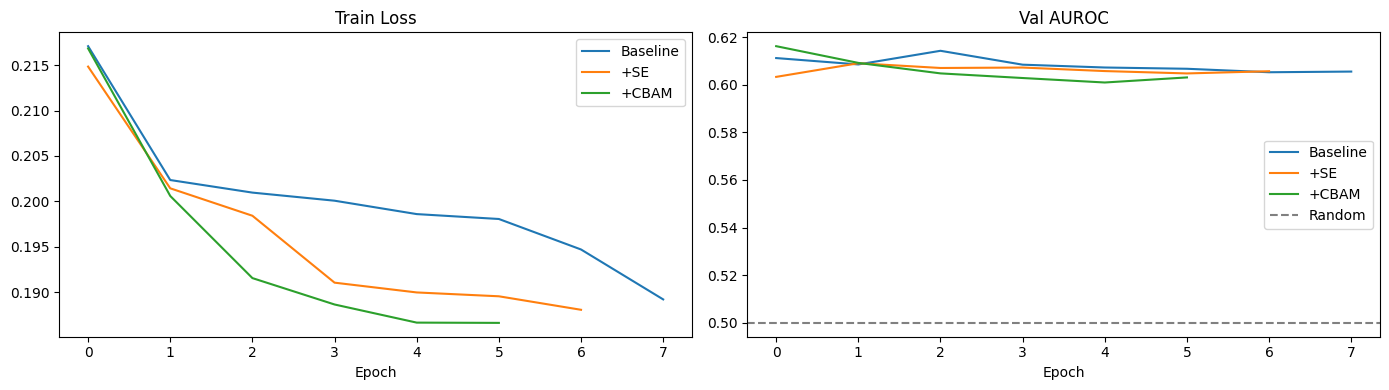

In [14]:
# ── Training curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for losses, label in [(losses_a, 'Baseline'), (losses_b, '+SE'), (losses_c, '+CBAM')]:
    axes[0].plot(losses, label=label)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

for aurocs, label in [(aurocs_a, 'Baseline'), (aurocs_b, '+SE'), (aurocs_c, '+CBAM')]:
    axes[1].plot(aurocs, label=label)
axes[1].axhline(0.5, color='gray', linestyle='--', label='Random')
axes[1].set_title('Val AUROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/ae_training_curves.png', dpi=150)
plt.show()

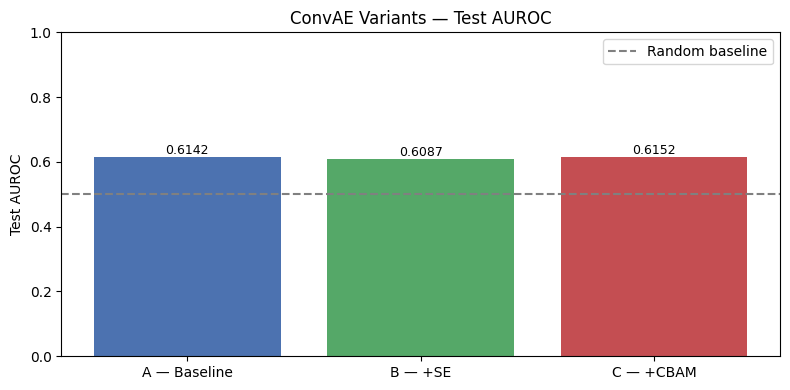

In [ ]:
names  = list(results.keys())
aurocs = [results[n]['auroc'] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, aurocs, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.axhline(0.5, color='gray', linestyle='--', label='Random baseline')
ax.set_ylim(0, 1)
ax.set_ylabel('Test AUROC')
ax.set_title('ConvAE Variants — Test AUROC')
for bar, v in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('results/ae_auroc_comparison.png', dpi=150)
plt.show()

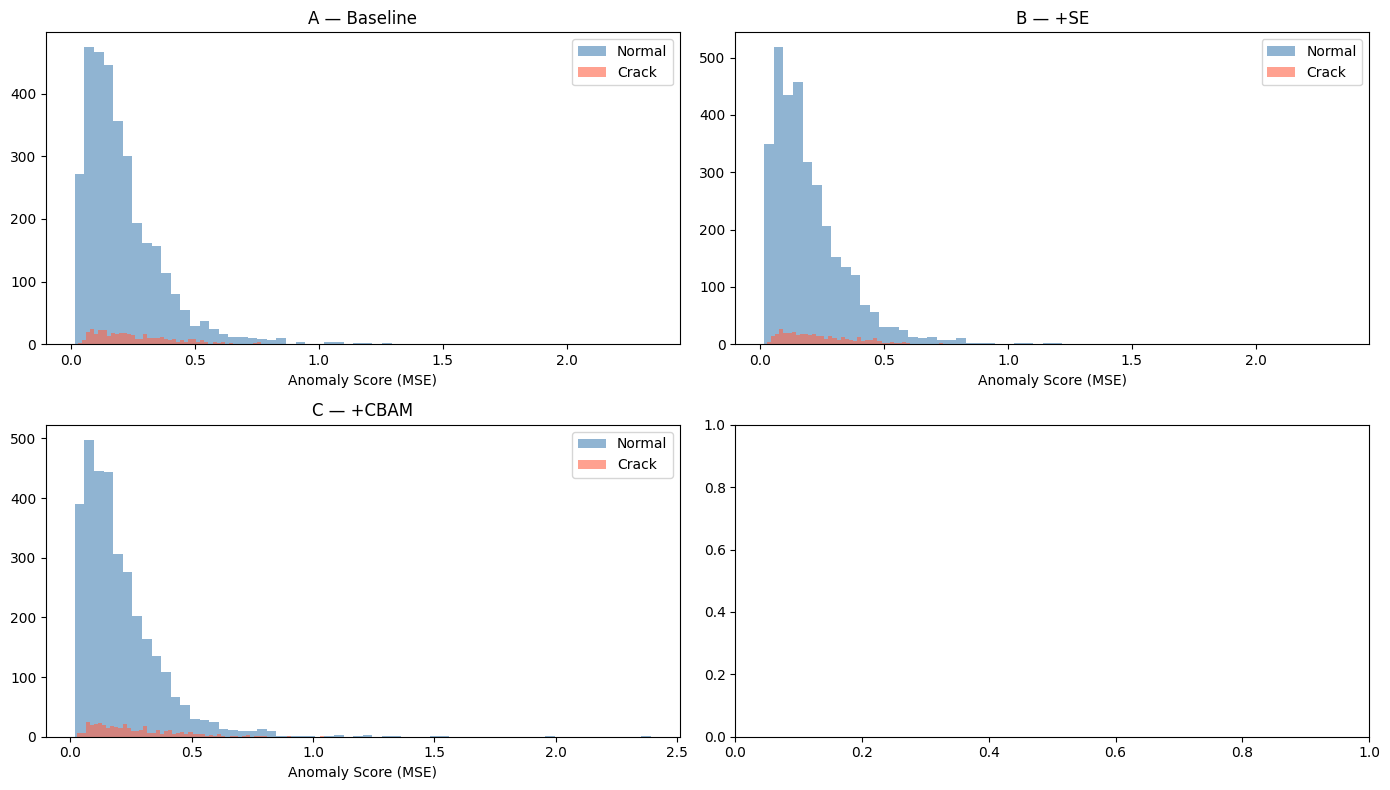

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, scores) in zip(axes.flat,
    [('A — Baseline', scores_a), ('B — +SE', scores_b),
     ('C — +CBAM', scores_c)]):
    ax.hist(scores[test_labels == 0], bins=60, alpha=0.6, label='Normal', color='steelblue')
    ax.hist(scores[test_labels == 1], bins=60, alpha=0.6, label='Crack',  color='tomato')
    ax.set_title(name)
    ax.set_xlabel('Anomaly Score (MSE)')
    ax.legend()
plt.tight_layout()
plt.savefig('results/ae_score_histograms.png', dpi=150)
plt.show()

## Results and Issues
Five autoencoder variants were tested: a baseline ConvAE, ConvAE with SE attention, ConvAE with CBAM attention, ConvAE with perceptual loss, and a pretrained ResNet18 encoder with a learned decoder. All variants produced very similar performance, clustering within a narrow validation AUROC range of roughly 0.59-0.62. The baseline ConvAE achieved the strongest overall result among the plain reconstruction models, reaching a best validation AUROC of 0.6142 at epoch 3 before declining. SE attention slightly worsened AUROC to 0.6087, although it increased recall by detecting more crack patches at the cost of many more false positives. CBAM gave the marginally highest AUROC at 0.6152, but this was effectively indistinguishable from the baseline and the confusion matrix remained almost identical. Perceptual loss also failed to improve discrimination, ending at 0.6125, while the pretrained ResNet18 encoder variant performed worst, with validation AUROC staying below 0.60.

Across all five variants, the training pattern was consistent: reconstruction loss decreased steadily, but AUROC peaked very early, usually within the first 1-3 epochs, and then stagnated or declined. This indicates that the models were learning to reconstruct both normal and anomalous patches increasingly well, reducing the reconstruction-error gap needed for anomaly detection.

### Issues
The main issue is the reconstruction completeness problem. Once the autoencoder has enough representational capacity, it no longer treats cracks as difficult-to-reconstruct outliers and instead begins reconstructing them almost as well as normal concrete. This causes the anomaly score distributions for normal and crack patches to overlap heavily, which limits AUROC regardless of architectural refinement.

The additional modifications did not solve this core problem. SE and CBAM introduced attention but did not change the underlying reconstruction objective, so any gains in localisation or channel emphasis were too weak to produce clear separation. Perceptual loss also failed because VGG features, although useful for semantic image similarity, are not well aligned with subtle concrete texture defects. The pretrained ResNet18 encoder was particularly mismatched for reconstruction, since its ImageNet features are tuned for semantic abstraction and discard the low-level texture detail that the decoder needs to make crack-sensitive reconstructions.

Overall, these experiments suggest that reconstruction-based anomaly detection is fundamentally weak for this task. The next step should focus on feature-space or memory-based methods such as PatchCore, which avoid the need to reconstruct anomalies at all.